Urban Data Science & Smart Cities <br>
URSP688Y Spring 2026<br>
Instructor: Chester Harvey <br>
Urban Studies & Planning <br>
National Center for Smart Growth <br>
University of Maryland

# Demo 6 - Geospatial Data

- Coordinate systems
- Points from XY
- Loading shapefiles and geojsons
- Proximity analysis
    - Measuring distance
    - Buffering
- Overlay analysis
- Spatial joining

## Geospatial data fundamentals
- Basic geometry types:
    - Points
    - Linestrings
    - Polygons

<img alt="points, lines, and polygons" width=500 src="https://datacarpentry.org/organization-geospatial/fig/dc-spatial-vector/pnt_line_poly.png">

- Spatial analysis (with vector data) is just Euclidean geometry (remember the Pythagorean theorem?)

<img alt="pythagorean theorem" width=500 src="https://www.katesmathlessons.com/uploads/1/6/1/0/1610286/published/how-to-use-the-pythagorean-theorem-to-find-distance-between-points-on-coordinate-plane-2.png?1595954050">

# GeoPandas: Package for working with shapefile-like tables (GeoDataFrames)

In Anaconda Prompt (Windows) or Terminal (Mac):
```
conda install geopandas
```

## Geospatial data are everywhere

DC affordable housing: https://opendata.dc.gov/datasets/DCGIS::affordable-housing/about

In [1]:
# Import dependencies
import pandas as pd
import geopandas as gpd

## Make points from CSV

In [2]:
# Read the csv using Pandas

housing_project_df = pd.read_csv('Affordable_Housing.csv')

In [3]:
housing_project_df.head().T

,0,1,2,3,4
X,-8574568.2361,-8574165.6924,-8569003.4928,-8574084.5559,-8572660.3406
Y,4708432.6634,4711586.2973,4710429.5845,4710963.9938,4703628.1274
OBJECTID,359003,359004,359005,359006,359007
MAR_WARD,Ward 2,Ward 1,Ward 5,Ward 1,Ward 6
ADDRESS,"1301 11th Street Northwest, Washington, Distri...","3115 Georgia Avenue Northwest, Washington, Dis...","1914 Bryant Street Northeast, Washington, Dist...","2711 Georgia Avenue Northwest, Washington, Dis...","1319 South Capitol Street Southwest, Washingto..."
PROJECT_NAME,New Bethany Apartments (1301 11th Street NW),3115 Georgia Ave. NW,1914 Bryant St. NE,2711 Georgia Ave. NW,1319 South Capitol St. SW
STATUS_PUBLIC,Pipeline,Under Construction,Under Construction,Completed 2015 to Date,Completed 2015 to Date
AGENCY_CALCULATED,DHCD,DHCD,DHCD,DHCD,DHCD
TOTAL_AFFORDABLE_UNITS,5,1,1,12,25
LATITUDE,38.907508,38.92955,38.921466,38.925115,38.873483


In [4]:
# Construct points from the longitude and latitude columns

housing_project_points = gpd.points_from_xy(housing_project_df['LONGITUDE'], housing_project_df['LATITUDE'])

In [5]:
housing_project_points

<GeometryArray>
[<POINT (-77.027 38.908)>,  <POINT (-77.023 38.93)>, <POINT (-76.977 38.921)>,
 <POINT (-77.022 38.925)>,  <POINT (-77.01 38.873)>, <POINT (-76.972 38.905)>,
 <POINT (-77.023 38.956)>,  <POINT (-76.986 38.91)>, <POINT (-76.994 38.941)>,
 <POINT (-76.994 38.941)>,
 ...
 <POINT (-77.018 38.913)>, <POINT (-76.997 38.829)>, <POINT (-76.998 38.927)>,
 <POINT (-77.015 38.901)>, <POINT (-77.032 38.958)>, <POINT (-76.935 38.883)>,
  <POINT (-77.016 38.95)>,  <POINT (-76.97 38.872)>,  <POINT (-77.02 38.956)>,
  <POINT (-77.02 38.956)>]
Length: 922, dtype: geometry

In [6]:
# Make into a geodataframe

housing_project_gdf = gpd.GeoDataFrame(housing_project_df, geometry=housing_project_points, crs=4326)

In [7]:
housing_project_gdf.head()

,X,Y,OBJECTID,MAR_WARD,ADDRESS,PROJECT_NAME,STATUS_PUBLIC,AGENCY_CALCULATED,TOTAL_AFFORDABLE_UNITS,LATITUDE,...,FULLADDRESS,GIS_LAST_MOD_DTTM,AFFORDABLE_UNITS_PRESERVED,UNITS_NEWLY_COVENANT_EXISTING,AFFORDABLE_UNITS_PRODUCTION,UNITS_NET_NEW,UNITS_MARKET,UNITS_TOTAL,CONSTRUCTION_END_DATE,geometry
0,-8.574568e+06,4.708433e+06,359003,Ward 2,"1301 11th Street Northwest, Washington, Distri...",New Bethany Apartments (1301 11th Street NW),Pipeline,DHCD,5,38.907508,...,1301 11TH STREET NW,2026/03/02 05:00:19+00,0,0,5,5,39,44,NaN,POINT (-77.02665 38.90751)
1,-8.574166e+06,4.711586e+06,359004,Ward 1,"3115 Georgia Avenue Northwest, Washington, Dis...",3115 Georgia Ave. NW,Under Construction,DHCD,1,38.929550,...,3115 GEORGIA AVENUE NW,2026/03/02 05:00:19+00,0,0,1,1,9,10,2026/02/01 00:00:00+00,POINT (-77.02304 38.92955)
2,-8.569003e+06,4.710430e+06,359005,Ward 5,"1914 Bryant Street Northeast, Washington, Dist...",1914 Bryant St. NE,Under Construction,DHCD,1,38.921466,...,1914 BRYANT STREET NE,2026/03/02 05:00:19+00,0,0,1,1,9,10,2026/03/01 00:00:00+00,POINT (-76.97667 38.92147)
3,-8.574085e+06,4.710964e+06,359006,Ward 1,"2711 Georgia Avenue Northwest, Washington, Dis...",2711 Georgia Ave. NW,Completed 2015 to Date,DHCD,12,38.925115,...,2711 GEORGIA AVENUE NW,2026/03/02 05:00:19+00,0,0,12,12,81,93,2024/08/01 00:00:00+00,POINT (-77.02226 38.92512)
4,-8.572660e+06,4.703628e+06,359007,Ward 6,"1319 South Capitol Street Southwest, Washingto...",1319 South Capitol St. SW,Completed 2015 to Date,DHCD,25,38.873483,...,1319 SOUTH CAPITOL STREET SW,2026/03/02 05:00:19+00,0,0,25,25,285,310,2024/02/20 00:00:00+00,POINT (-77.00959 38.87348)


<Axes: >

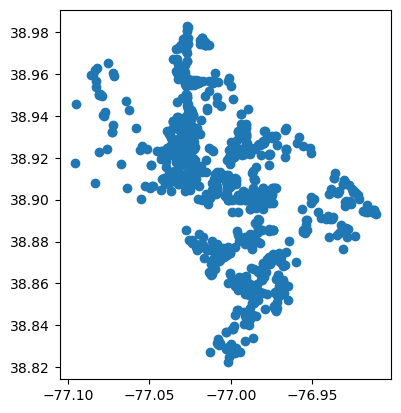

In [8]:
# Plot the points

housing_project_gdf.plot()

## Measuring proximity

### How far is each affordable housing project from Metro Center?

In [9]:
# Will the distance method provide accurate distances?

# .distance() method

metro_center_lon = -77.0283526
metro_center_lat = 38.8972172

metro_center_point = gpd.points_from_xy([metro_center_lon], [metro_center_lat], crs=4326)

## UTM Zones

[Universal Transverse Mercator](https://en.wikipedia.org/wiki/Universal_Transverse_Mercator_coordinate_system) Zones

The UTM system divides the globe into 120 zones, 60 each in the northern and southern hemispheres. It uses Transverse Mercator projections to minimize shape and distance distortion for localized measurements within each zone.

<img alt="utm slices" width=500 src="https://gisgeography.com/wp-content/uploads/2016/05/UTM-Zones-Globe-2.png">

<img alt="utm standard line" width=500 src="https://gisgeography.com/wp-content/uploads/2016/05/Universe-Transverse-Mercator-Cylinder.png">

1. [What UTM zone am I in?](https://mangomap.com/robertyoung/maps/69585/what-utm-zone-am-i-in-#)
2. [What is the EPSG code for that zone?](https://www.google.com/search?q=epsg+code+for+UTM18N&rlz=1C5GCCM_en&oq=epsg+code+for+UTM18N&gs_lcrp=EgZjaHJvbWUyBggAEEUYOTIHCAEQIRigATIHCAIQIRigATIHCAMQIRigATIHCAQQIRigATIHCAUQIRigATIHCAYQIRiPAjIHCAcQIRiPAtIBCDcxMDJqMGo3qAIAsAIA&sourceid=chrome&ie=UTF-8)

In [10]:
# Reproject into UTM 18 North, the local UTM zone (EPSG: 32618)

housing_project_gdf = housing_project_gdf.to_crs(32618)
metro_center_point = metro_center_point.to_crs(32618)

In [11]:
housing_project_gdf.distance(metro_center_point[0])

0      1151.863663
1      3618.782065
2      5229.128583
3      3141.778767
4      3097.069477
          ...     
917    8270.094061
918    5904.137845
919    5824.031922
920    6519.755642
921    6516.566132
Length: 922, dtype: float64

In [12]:
# Add back on to the geodataframe as a column
housing_project_gdf['meters_to_metro_center'] = housing_project_gdf.distance(metro_center_point[0])

<Axes: >

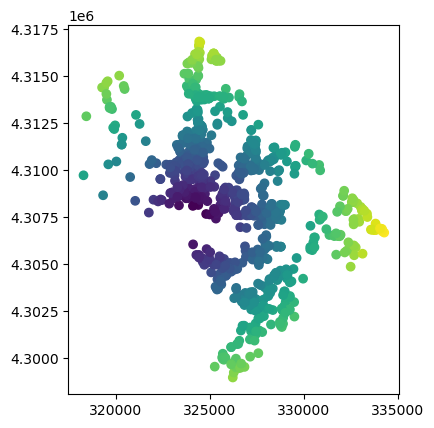

In [13]:
#.plot(column) # Make colorpleth map of distances

housing_project_gdf.plot('meters_to_metro_center')

In [14]:
m = housing_project_gdf.explore(column='meters_to_metro_center', tiles='CartoDB positron')
m.save('map.html')

### Which projects are within 1 mile of Metro Center or Columbia Heights?

#### Another approach: Buffer and spatial join

In [15]:
# Define multiple locations
metro_locations = {
    'Metro Center': {
        'lon': -77.0312124, 
        'lat': 38.898202
    },
    'Columbia Heights': {
        'lon': -77.0350154, 
        'lat': 38.92890
    },
    'Union Station': {
        'lon': -77.0089958, 
        'lat': 38.8984109
    }
}

# Convert to a geodataframe
metro_locations_df = pd.DataFrame.from_dict(metro_locations, orient='index')
metro_locations_points = gpd.points_from_xy(metro_locations_df['lon'], metro_locations_df['lat'])
metro_locations_gdf = gpd.GeoDataFrame(metro_locations_df, geometry=metro_locations_points, crs=4326)
metro_locations_gdf = metro_locations_gdf.to_crs(32618)

In [16]:
# Buffer metro locations

def miles_to_meters(miles):
    return miles * 1609.34

threshold_dist = miles_to_meters(1) # one mile
metro_locations_buffer = metro_locations_gdf.buffer(threshold_dist)
metro_locations_buffer_gdf = gpd.GeoDataFrame(metro_locations_gdf, geometry=metro_locations_buffer, crs=32618)

<Axes: >

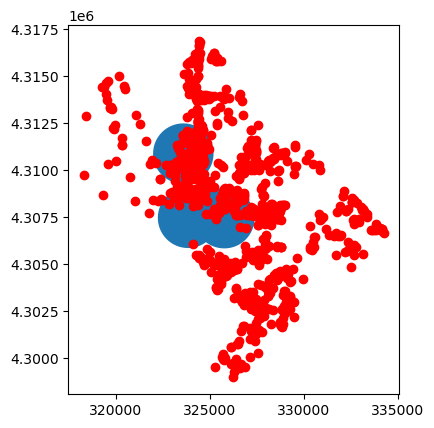

In [17]:
# Plot metro buffers and projects together
ax = metro_locations_buffer_gdf.plot()
housing_project_gdf.plot(ax=ax, color='red')

<Axes: >

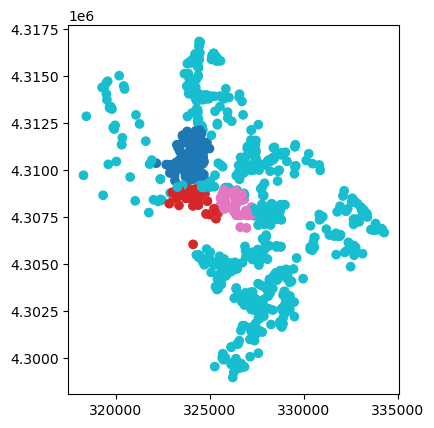

In [18]:
# Which projects are within 1 mile of these metro staions, and which aren't
# (keep those that don't overlap with buffers around by using a left join)
housing_project_gdf = gpd.sjoin(housing_project_gdf, metro_locations_buffer_gdf, how='left')
housing_project_gdf = housing_project_gdf.rename(columns={'index_right':'metro_station'})
housing_project_gdf['metro_station'] = housing_project_gdf['metro_station'].fillna('none')                           
housing_project_gdf.plot(column='metro_station')

## Overlay

### How many projects are in each census tract?

- [Population by Tract from Census Reporter](https://censusreporter.org/data/table/?table=B01003&geo_ids=16000US1150000,140|16000US1150000&primary_geo_id=16000US1150000)

In [19]:
# Load tract polygons from geojson
tracts_gdf = gpd.read_file('acs2024_5yr_B01003_14000US11001010100.geojson')

In [20]:
tracts_gdf.head()

,geoid,name,B01003001,"B01003001, Error",geometry
0,14000US11001000101,"Census Tract 1.01, District of Columbia, DC",1262.0,167.0,"MULTIPOLYGON (((-77.05714 38.91054, -77.05702 ..."
1,14000US11001000102,"Census Tract 1.02, District of Columbia, DC",2981.0,456.0,"MULTIPOLYGON (((-77.06927 38.90058, -77.06871 ..."
2,14000US11001000201,"Census Tract 2.01, District of Columbia, DC",3229.0,38.0,"MULTIPOLYGON (((-77.07927 38.91268, -77.07902 ..."
3,14000US11001000202,"Census Tract 2.02, District of Columbia, DC",4068.0,572.0,"MULTIPOLYGON (((-77.07991 38.90507, -77.07989 ..."
4,14000US11001000300,"Census Tract 3, District of Columbia, DC",5988.0,746.0,"MULTIPOLYGON (((-77.08262 38.9212, -77.08256 3..."


<Axes: >

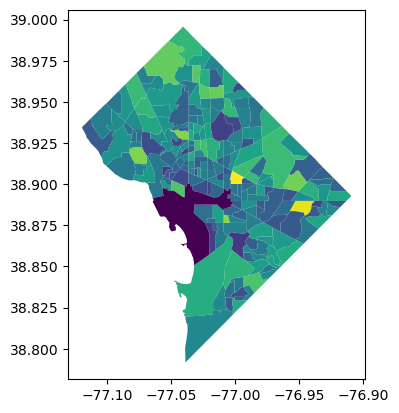

In [21]:
tracts_gdf.plot('B01003001')

In [22]:
# Project into local UTM and remove remove record for all of DC

In [23]:
# Ensure projects and tracts are in the same projection (CRS: coordinate reference system)

# assert (keyword)

In [24]:
# Spatially join projects to tracts

In [25]:
# Count unique projects in each tract (groupby, nunique)

In [26]:
# Join counts onto tracts (tabular join)

In [27]:
# Calculate projects per population

In [28]:
# Calculate units per census tract